# XAI Method Feature Importance Consistency

This notebook investigates how the **choice of explainability method** affects the interpretation of feature importance — comparing three XAI methods **within** the same model and preprocessing strategy.

For every combination of model × strategy, the three XAI methods are compared against each other:

| Model | Method A | Method B | Method C |
|---|---|---|---|
| Logistic Regression | SHAP | Permutation | Coefficient |
| Random Forest | SHAP | Permutation | Mean Decrease Impurity |
| XGBoost | SHAP | Permutation | XGBoost Gain |
| Decision Tree | SHAP | Permutation | Gini Importance |

Comparisons are always **same model × same strategy, different XAI method** — never cross-model.

**Methods used:**
- Top-10 overlap — how many of the top 10 features are shared between two XAI methods
- Spearman rank correlation — how similar the full feature rankings are (rank-based, so importance scale does not matter)
- Jaccard similarity — set-based overlap of the top-10 feature lists

> **Note on importance scores:** Each XAI method uses a different scale (mean |SHAP|, ROC AUC drop, coefficients, impurity/gain). Importance values are therefore **never compared directly** — only ranks and top-N membership are used.


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import spearmanr
from itertools import combinations

plt.rcParams.update({
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'figure.dpi':        120,
})

FIGURE_DIR = "../results/figures/xai_method_consistency/"
os.makedirs(FIGURE_DIR, exist_ok=True)

MODEL_COLORS = {
    "Logistic Regression": "#3266ad",
    "Random Forest":        "#2a8a5e",
    "XGBoost":              "#a04e0a",
    "Decision Tree":        "#7a3090",
}

# Model-specific method label per model
MODEL_SPECIFIC_METHOD = {
    "Logistic Regression": "Coefficient",
    "Random Forest":        "Mean Decrease Impurity",
    "XGBoost":              "XGBoost Gain",
    "Decision Tree":        "Gini Importance",
}

# XAI method display order and colours for plots
METHOD_COLORS = {
    "SHAP":        "#4a7fa5",
    "Permutation": "#e07b39",
    "Specific":    "#5b9e6b",
}

MODELS = list(MODEL_COLORS.keys())

PREFERRED_STRATEGY_ORDER = ["SMOTE", "Undersampling"]

TOP_N = 10


## Loading Feature Importance Data

All feature importance CSV files are loaded. All three XAI methods are retained. The data is grouped by `Model × Strategy` so that every comparison is strictly within the same trained model.

In [2]:
files = glob.glob("../results/**/*_feature_importance.csv")

if not files:
    raise FileNotFoundError("No feature importance files found. Run all model notebooks first.")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# Normalise method names: map model-specific labels to a generic "Specific" key
# so downstream code can reference them uniformly, while keeping the original
# label in a separate column for display purposes.
df["Method_Original"] = df["Method"]
specific_labels = set(MODEL_SPECIFIC_METHOD.values())
df["Method_Key"] = df["Method"].apply(
    lambda m: "Specific" if m in specific_labels else m
)

# Keep SMOTE and undersampling as separate strategies. This avoids mixed figures where
# the two preprocessing choices appear in the same ranking grid.
available_strategies = df["Strategy"].dropna().unique().tolist()
STRATEGIES = [s for s in PREFERRED_STRATEGY_ORDER if s in available_strategies]
STRATEGIES += sorted([s for s in available_strategies if s not in STRATEGIES])

if not STRATEGIES:
    raise ValueError("No preprocessing strategies were found in the feature-importance files.")

print("Models:     ", df["Model"].unique())
print("Strategies: ", df["Strategy"].unique())
print("Using strategies in this notebook:", STRATEGIES)
print("Methods:    ", df["Method_Original"].unique())
print("Total rows: ", len(df))


Models:      ['Logistic Regression' 'XGBoost' 'Decision Tree' 'Random Forest']
Strategies:  ['Undersampling' 'SMOTE']
Using strategies in this notebook: ['SMOTE', 'Undersampling']
Methods:     ['SHAP' 'Permutation' 'Coefficient' 'XGBoost Gain' 'Gini Importance'
 'Mean Decrease Impurity']
Total rows:  1032


## Helper Functions

The same three consistency metrics as in notebooks 05 and 06, re-parameterised to compare **XAI methods** instead of models or strategies.

> Because importance scores are on different scales across methods, **only ranks and top-N membership are used** — importance values are never compared directly.

In [3]:
def get_top_n(df, model, strategy, method_key, n=TOP_N):
    """Return the top-N feature names for a given model, strategy and XAI method."""
    subset = df[
        (df["Model"]       == model) &
        (df["Strategy"]    == strategy) &
        (df["Method_Key"]  == method_key)
    ]
    return set(subset.nsmallest(n, "Rank")["Feature"].tolist())


def get_full_ranking(df, model, strategy, method_key):
    """Return a Series of rank values indexed by feature name."""
    subset = df[
        (df["Model"]       == model) &
        (df["Strategy"]    == strategy) &
        (df["Method_Key"]  == method_key)
    ]
    return subset.set_index("Feature")["Rank"].sort_values()


def top_n_overlap(df, model, strategy, method_a, method_b, n=TOP_N):
    """Number of shared features in the top N between two XAI methods."""
    top_a = get_top_n(df, model, strategy, method_a, n)
    top_b = get_top_n(df, model, strategy, method_b, n)
    return len(top_a & top_b)


def spearman_correlation(df, model, strategy, method_a, method_b):
    """Spearman rank correlation of full feature rankings between two XAI methods."""
    rank_a = get_full_ranking(df, model, strategy, method_a)
    rank_b = get_full_ranking(df, model, strategy, method_b)
    common = rank_a.index.intersection(rank_b.index)
    if len(common) < 2:
        return np.nan
    corr, _ = spearmanr(rank_a[common], rank_b[common])
    return round(corr, 4)


def jaccard_similarity(df, model, strategy, method_a, method_b, n=TOP_N):
    """Jaccard similarity of top-N feature sets between two XAI methods."""
    top_a = get_top_n(df, model, strategy, method_a, n)
    top_b = get_top_n(df, model, strategy, method_b, n)
    if not top_a | top_b:
        return 0.0
    return round(len(top_a & top_b) / len(top_a | top_b), 4)


def build_method_matrix(df, model, strategy, metric_fn):
    """Build a 3×3 symmetric matrix of pairwise XAI method scores."""
    methods = ["SHAP", "Permutation", "Specific"]
    mat = pd.DataFrame(np.nan, index=methods, columns=methods)

    for m in methods:
        if metric_fn == spearman_correlation:
            mat.loc[m, m] = 1.0
        elif metric_fn == jaccard_similarity:
            mat.loc[m, m] = 1.0
        else:  # top_n_overlap
            mat.loc[m, m] = float(TOP_N)

    for a, b in combinations(methods, 2):
        val = metric_fn(df, model, strategy, a, b)
        mat.loc[a, b] = val
        mat.loc[b, a] = val

    # Replace generic "Specific" label with the model-specific display name
    specific_label = MODEL_SPECIFIC_METHOD.get(model, "Model-Specific")
    mat.index   = [specific_label if m == "Specific" else m for m in mat.index]
    mat.columns = [specific_label if m == "Specific" else m for m in mat.columns]
    return mat


def compute_pairwise_summary(df, n=TOP_N):
    """Compute all pairwise XAI method metrics for every Model × Strategy combination."""
    pairs = [("SHAP", "Permutation"), ("SHAP", "Specific"), ("Permutation", "Specific")]
    rows = []
    for model in MODELS:
        for strategy in STRATEGIES:
            for ma, mb in pairs:
                # Check data availability
                has_a = not df[
                    (df["Model"] == model) &
                    (df["Strategy"] == strategy) &
                    (df["Method_Key"] == ma)
                ].empty
                has_b = not df[
                    (df["Model"] == model) &
                    (df["Strategy"] == strategy) &
                    (df["Method_Key"] == mb)
                ].empty
                if not (has_a and has_b):
                    continue

                specific_name = MODEL_SPECIFIC_METHOD.get(model, "Model-Specific")
                label_a = specific_name if ma == "Specific" else ma
                label_b = specific_name if mb == "Specific" else mb

                rows.append({
                    "Model":              model,
                    "Strategy":           strategy,
                    "Method A":           label_a,
                    "Method B":           label_b,
                    "Top-N Overlap":      top_n_overlap(df, model, strategy, ma, mb, n),
                    "Spearman ρ":         spearman_correlation(df, model, strategy, ma, mb),
                    "Jaccard Similarity": jaccard_similarity(df, model, strategy, ma, mb, n),
                })
    return pd.DataFrame(rows)

---
# Section 1 — Top-10 Feature Rankings per XAI Method, Plotted Separately per Strategy

This section creates one standalone figure per preprocessing strategy, for example one figure for **SMOTE** and one separate figure for **Undersampling**.

Each figure shows model × XAI-method top-10 rankings. Rows represent the four models and columns represent the three XAI methods.

Features appearing in all three top-10 lists for the same model are highlighted in the model colour. Features appearing in two of the three lists are shown with a lighter version of the model colour. Method-unique features are shown in grey.

Note: each panel uses the importance scale of its own XAI method, so bar lengths should only be compared within a panel, not across methods.


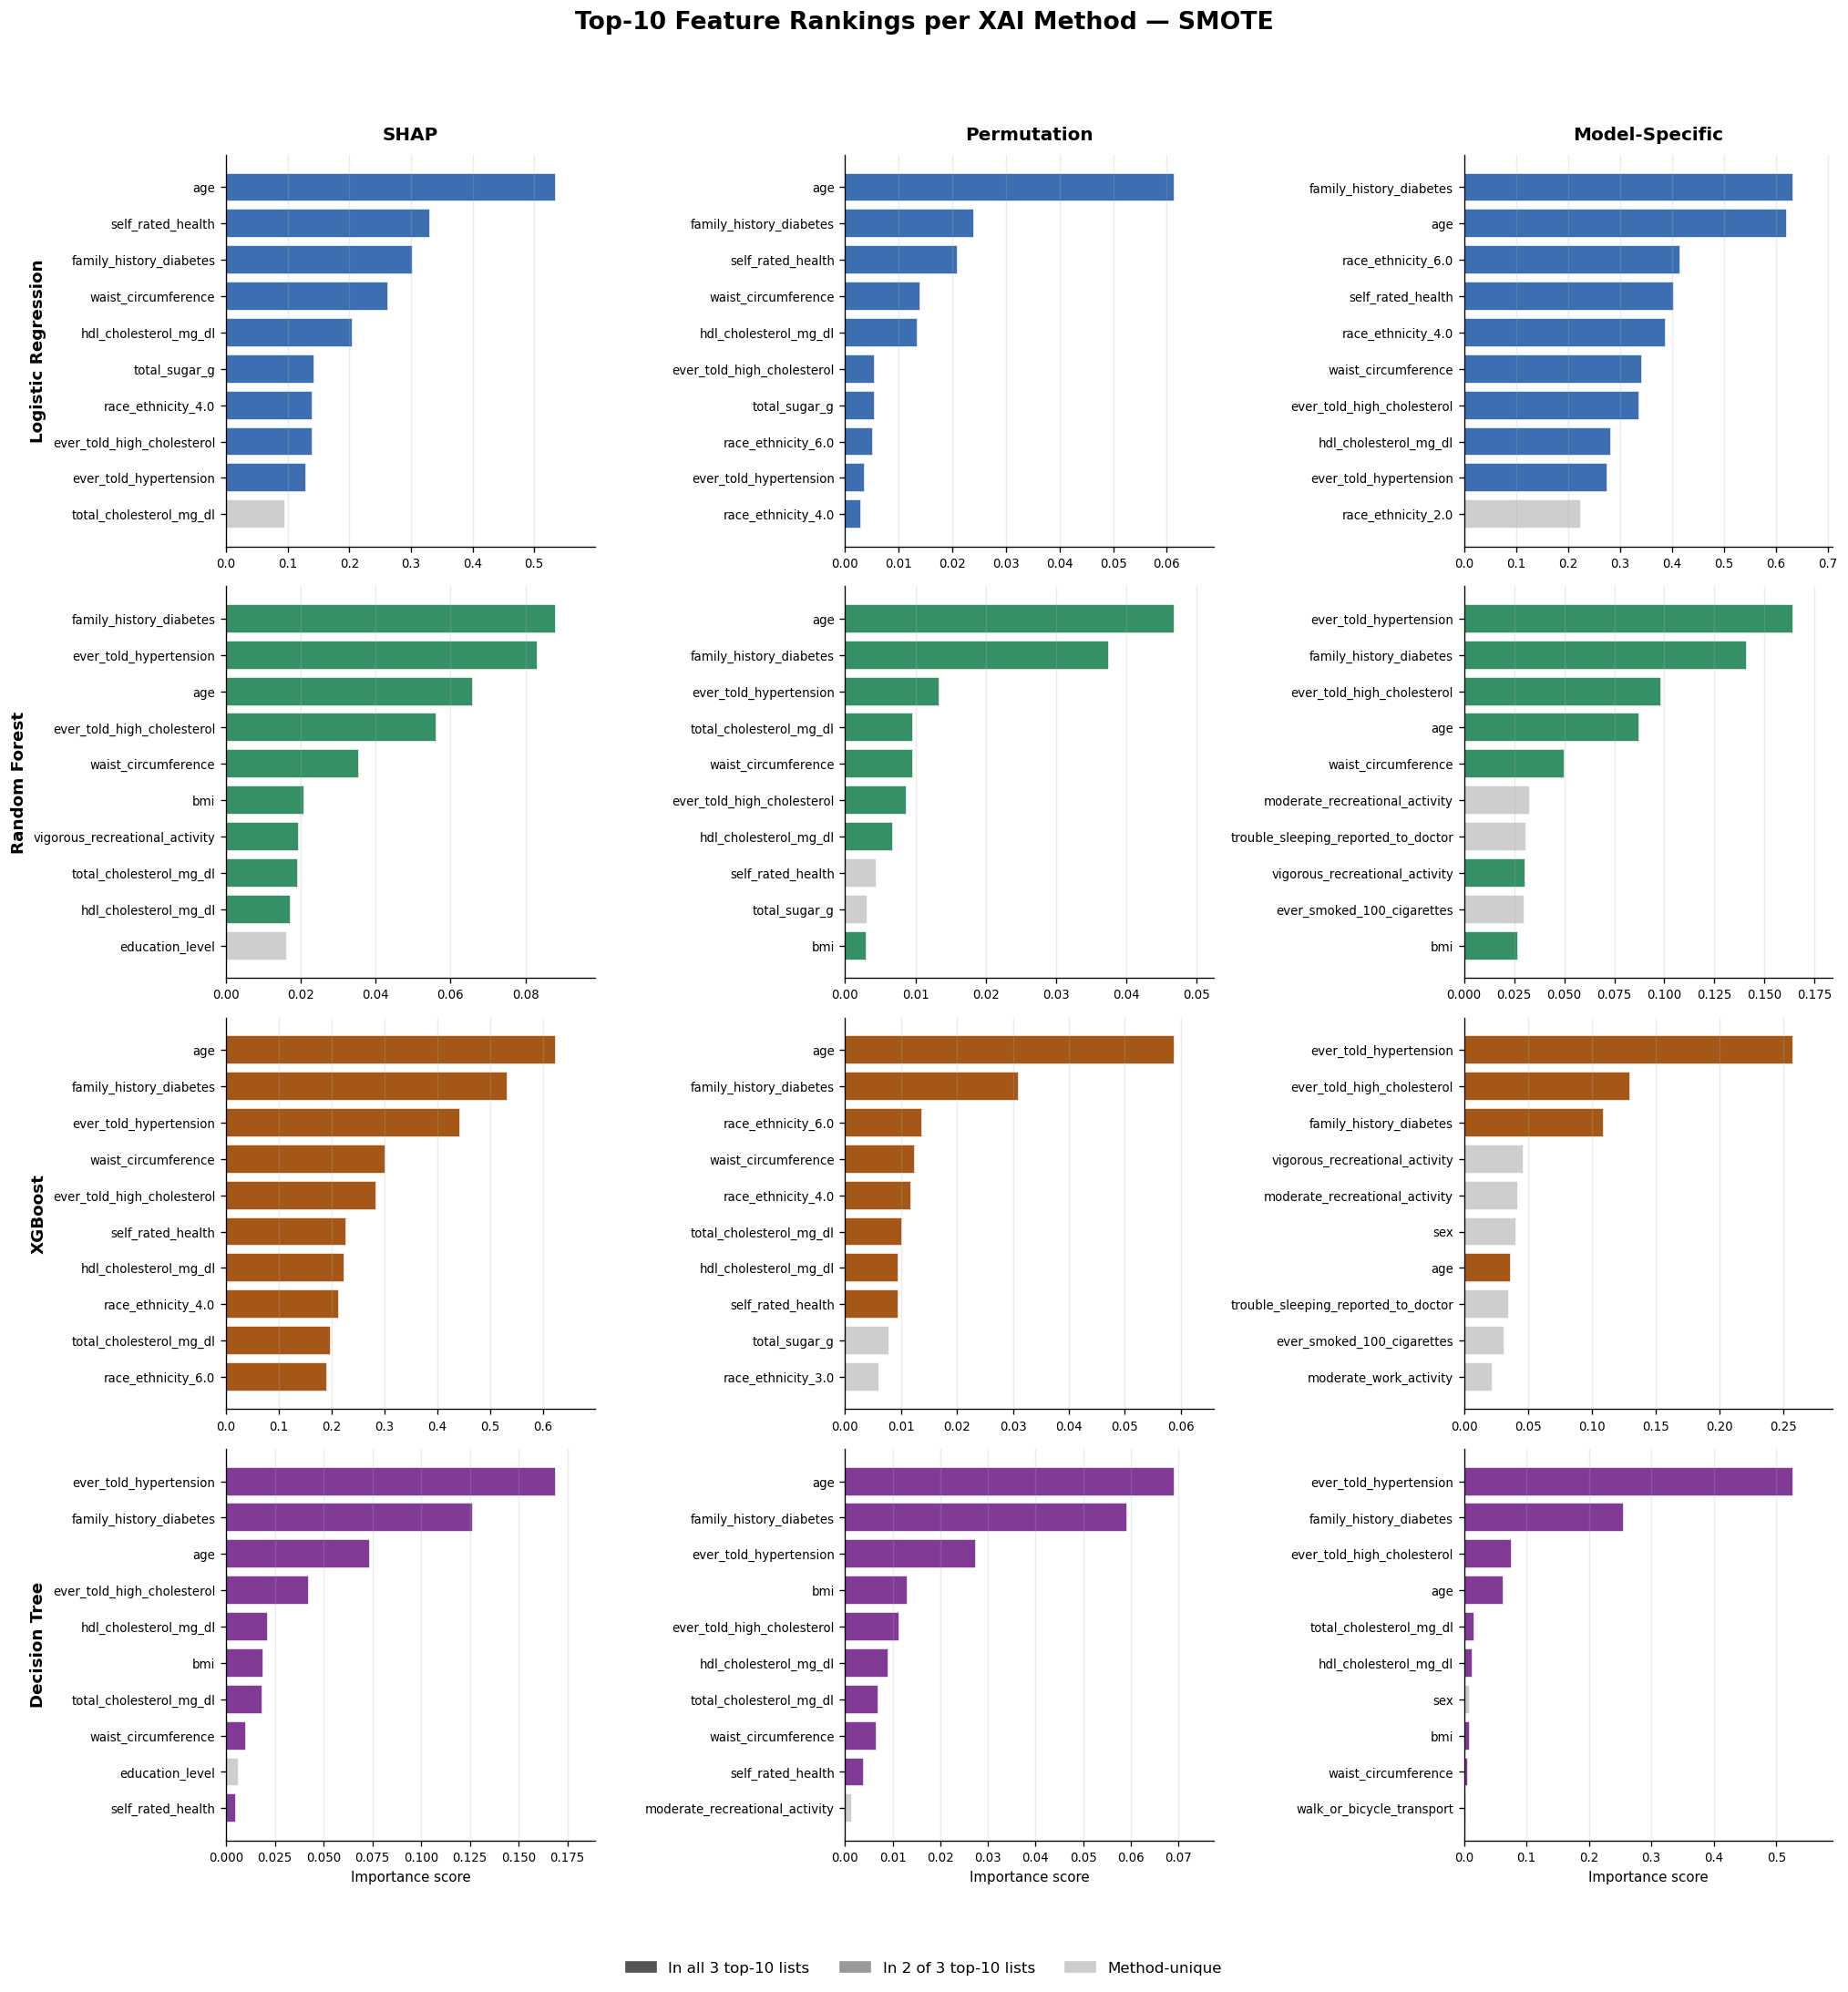

Saved figure to: ../results/figures/xai_method_consistency/top10_xai_method_rankings_4x3_grid_smote.png


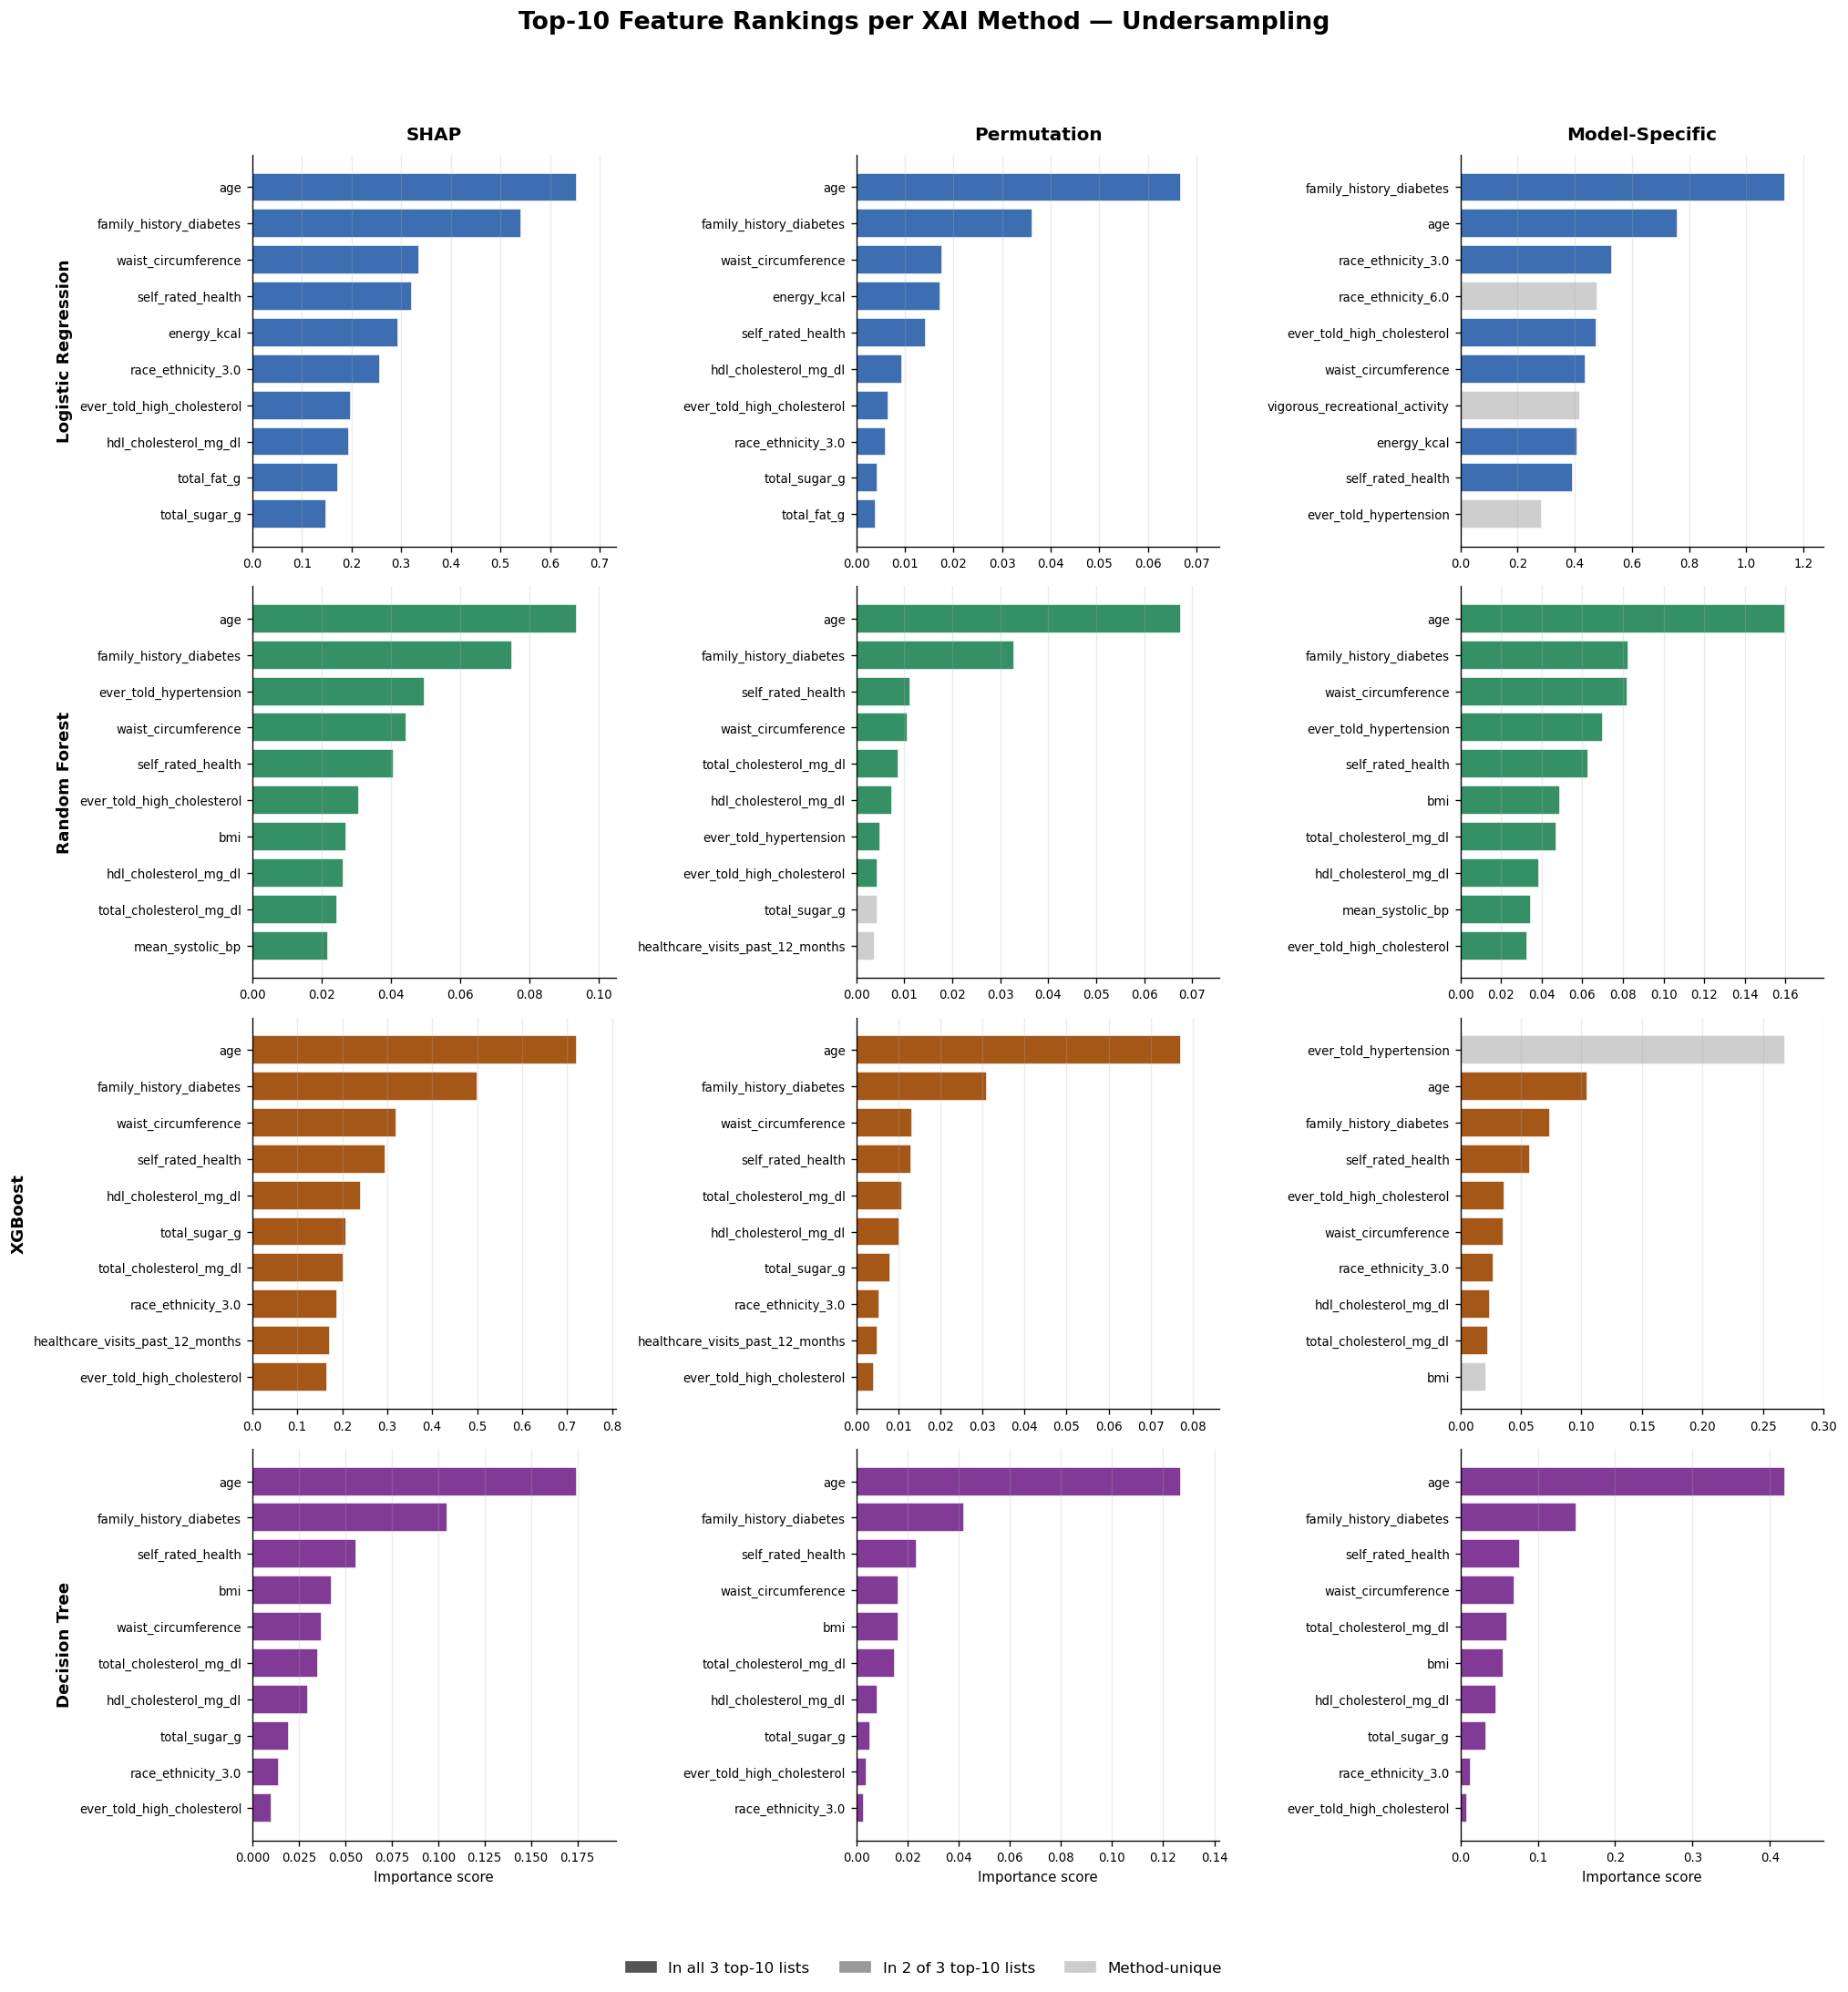

Saved figure to: ../results/figures/xai_method_consistency/top10_xai_method_rankings_4x3_grid_undersampling.png


In [4]:
method_keys = ["SHAP", "Permutation", "Specific"]


def plot_xai_method_rankings_for_strategy(df, strategy, top_n=TOP_N):
    """Create a standalone 4×3 ranking grid for one preprocessing strategy."""
    fig, axes = plt.subplots(
        nrows=len(MODELS),
        ncols=len(method_keys),
        figsize=(17, 18),
        constrained_layout=False
    )

    for row_idx, model in enumerate(MODELS):
        method_labels = ["SHAP", "Permutation", "Model-Specific"]
        model_color = MODEL_COLORS[model]

        # Compute agreement within this model across the three XAI top-N lists.
        tops = [get_top_n(df, model, strategy, mk, n=top_n) for mk in method_keys]
        consensus = tops[0] & tops[1] & tops[2]
        any_two = (tops[0] & tops[1]) | (tops[0] & tops[2]) | (tops[1] & tops[2])

        for col_idx, (mk, label) in enumerate(zip(method_keys, method_labels)):
            ax = axes[row_idx, col_idx]

            subset = df[
                (df["Model"] == model) &
                (df["Strategy"] == strategy) &
                (df["Method_Key"] == mk)
            ].nsmallest(top_n, "Rank")

            if subset.empty:
                ax.set_title(f"{label}\n(no data)", fontsize=10)
                ax.axis("off")
                continue

            subset = subset.sort_values("Importance", ascending=True)

            def bar_color(feature):
                if feature in consensus:
                    return model_color
                if feature in any_two:
                    return model_color + "88"
                return "#cccccc"

            colors = [bar_color(feature) for feature in subset["Feature"]]

            ax.barh(
                subset["Feature"],
                subset["Importance"],
                color=colors,
                edgecolor="white",
                alpha=0.95
            )

            if row_idx == 0:
                ax.set_title(label, fontsize=12, fontweight="bold", pad=10)

            if col_idx == 0:
                ax.set_ylabel(model, fontsize=11, fontweight="bold")
            else:
                ax.set_ylabel("")

            if row_idx == len(MODELS) - 1:
                ax.set_xlabel("Importance score", fontsize=9)
            else:
                ax.set_xlabel("")

            ax.tick_params(axis="y", labelsize=8)
            ax.tick_params(axis="x", labelsize=8)
            ax.grid(axis="x", alpha=0.25)
            ax.grid(axis="y", visible=False)

            xmax = subset["Importance"].max()
            if pd.notna(xmax) and xmax > 0:
                ax.set_xlim(0, xmax * 1.12)

    legend_handles = [
        mpatches.Patch(color="#555555", label=f"In all 3 top-{top_n} lists"),
        mpatches.Patch(color="#999999", label=f"In 2 of 3 top-{top_n} lists"),
        mpatches.Patch(color="#cccccc", label="Method-unique")
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=3,
        fontsize=10,
        frameon=False,
        bbox_to_anchor=(0.5, -0.01)
    )

    fig.suptitle(
        f"Top-{top_n} Feature Rankings per XAI Method — {strategy}",
        fontsize=16,
        fontweight="bold",
        y=0.995
    )

    plt.tight_layout(rect=[0, 0.035, 1, 0.965])

    safe_strategy = strategy.lower().replace(" ", "_").replace("-", "_")
    output_path = f"{FIGURE_DIR}top{top_n}_xai_method_rankings_4x3_grid_{safe_strategy}.png"
    plt.savefig(output_path, bbox_inches="tight", dpi=300)
    plt.show()

    print(f"Saved figure to: {output_path}")


for strategy in STRATEGIES:
    plot_xai_method_rankings_for_strategy(df, strategy, top_n=TOP_N)


---
# Section 3 — Spearman ρ Overview, Plotted Separately per Strategy

This section creates a separate Spearman heatmap for each preprocessing strategy. This keeps **SMOTE** and **Undersampling** independent, so either figure can be included or excluded from the paper without editing a combined plot.


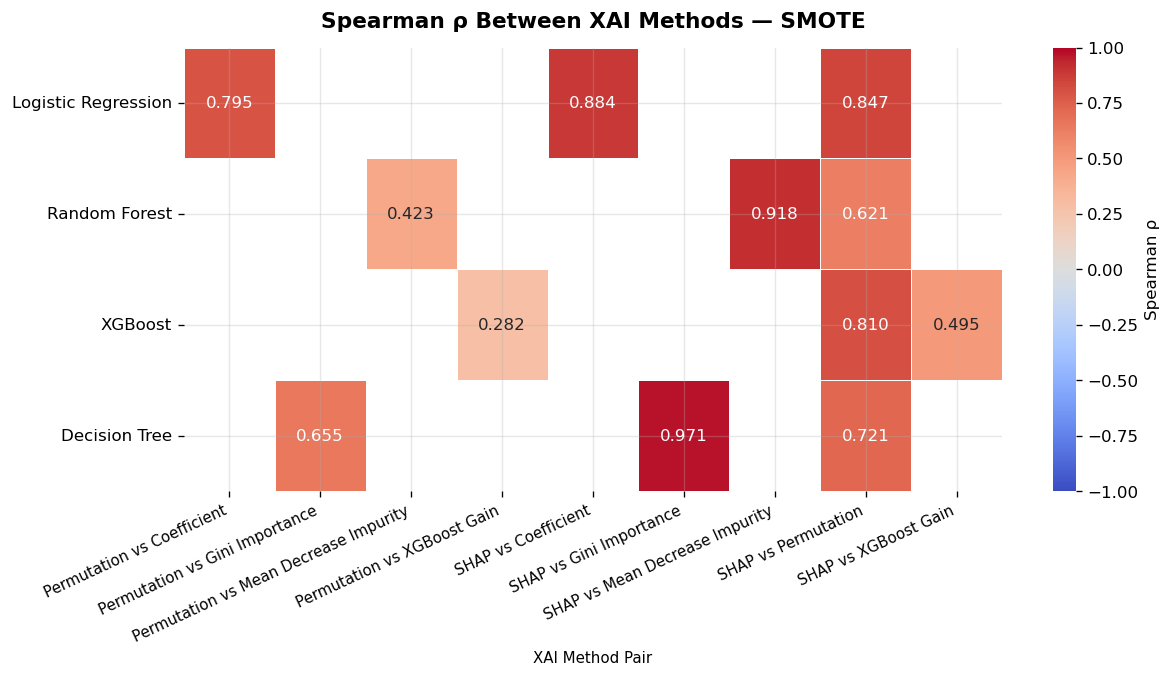

Saved figure to: ../results/figures/xai_method_consistency/spearman_heatmap_smote.png
SMOTE mean Spearman ρ: 0.702
Pair-level means:
Pair
Permutation vs Coefficient               0.796
Permutation vs Gini Importance           0.655
Permutation vs Mean Decrease Impurity    0.423
Permutation vs XGBoost Gain              0.282
SHAP vs Coefficient                      0.884
SHAP vs Gini Importance                  0.971
SHAP vs Mean Decrease Impurity           0.918
SHAP vs Permutation                      0.750
SHAP vs XGBoost Gain                     0.495



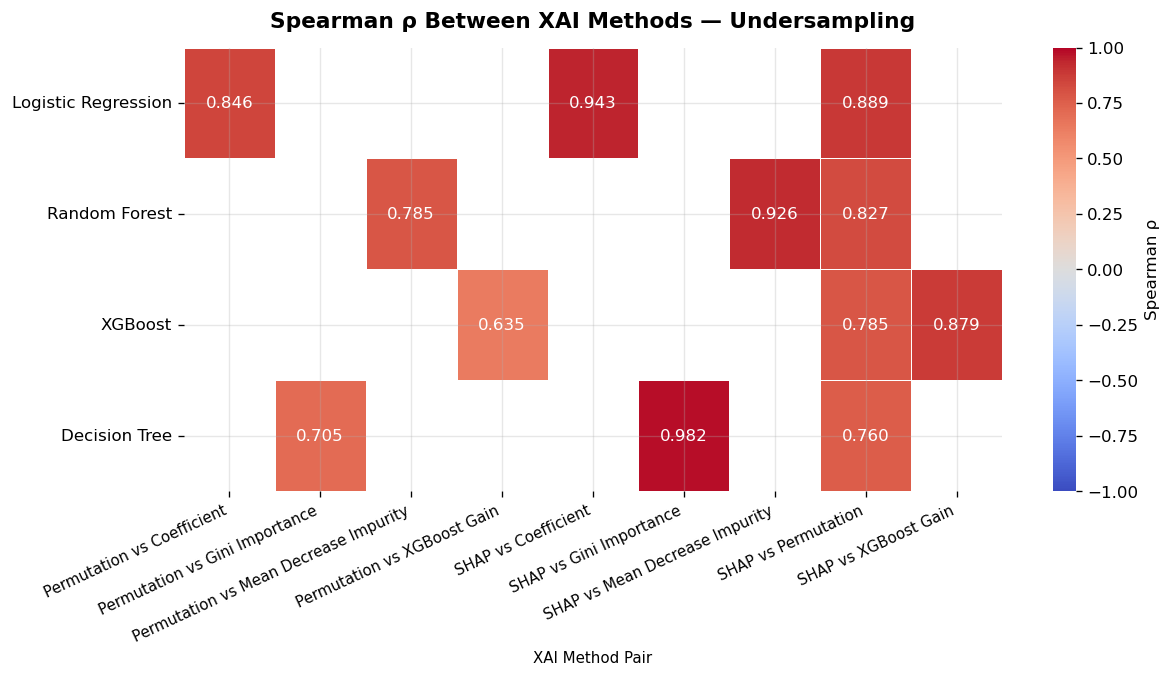

Saved figure to: ../results/figures/xai_method_consistency/spearman_heatmap_undersampling.png
Undersampling mean Spearman ρ: 0.830
Pair-level means:
Pair
Permutation vs Coefficient               0.846
Permutation vs Gini Importance           0.705
Permutation vs Mean Decrease Impurity    0.785
Permutation vs XGBoost Gain              0.635
SHAP vs Coefficient                      0.943
SHAP vs Gini Importance                  0.982
SHAP vs Mean Decrease Impurity           0.926
SHAP vs Permutation                      0.815
SHAP vs XGBoost Gain                     0.879



In [5]:
summary_df = compute_pairwise_summary(df)

# Build pair labels once for all later sections.
summary_df["Pair"] = summary_df["Method A"] + " vs " + summary_df["Method B"]


def strategy_row_order(pivot):
    return [
        m for m in MODELS
        if m in pivot.index
    ]


def plot_strategy_heatmap(summary_df, strategy, value_col, title, cmap, fmt, vmin=None, vmax=None, center=None, cbar_label=None, filename_prefix=None):
    strategy_df = summary_df[summary_df["Strategy"] == strategy].copy()

    if strategy_df.empty:
        print(f"No data found for strategy: {strategy}")
        return

    pivot = strategy_df.pivot_table(
        index="Model",
        columns="Pair",
        values=value_col
    )

    pivot = pivot.loc[strategy_row_order(pivot)]

    fig, ax = plt.subplots(figsize=(11, len(pivot) * 0.7 + 2))
    sns.heatmap(
        pivot.astype(float),
        annot=True,
        fmt=fmt,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        center=center,
        linewidths=0.5,
        linecolor="white",
        ax=ax,
        cbar_kws={"label": cbar_label} if cbar_label else None
    )

    ax.set_title(title.format(strategy=strategy), fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("XAI Method Pair", fontsize=9)
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right", fontsize=9)

    safe_strategy = strategy.lower().replace(" ", "_").replace("-", "_")
    output_path = f"{FIGURE_DIR}{filename_prefix}_{safe_strategy}.png"
    plt.savefig(output_path, bbox_inches="tight", dpi=300)
    plt.show()

    print(f"Saved figure to: {output_path}")
    print(f"{strategy} mean {value_col}: {strategy_df[value_col].mean():.3f}")
    print("Pair-level means:")
    print(strategy_df.groupby("Pair")[value_col].mean().round(3).to_string())
    print()


for strategy in STRATEGIES:
    plot_strategy_heatmap(
        summary_df=summary_df,
        strategy=strategy,
        value_col="Spearman ρ",
        title="Spearman ρ Between XAI Methods — {strategy}",
        cmap="coolwarm",
        fmt=".3f",
        vmin=-1,
        vmax=1,
        center=0,
        cbar_label="Spearman ρ",
        filename_prefix="spearman_heatmap"
    )


---
# Section 4 — Top-10 Overlap Overview, Plotted Separately per Strategy

This section creates one standalone Top-10 overlap heatmap per preprocessing strategy. Each cell shows how many of the top 10 features are shared between two XAI methods for the same model and strategy.


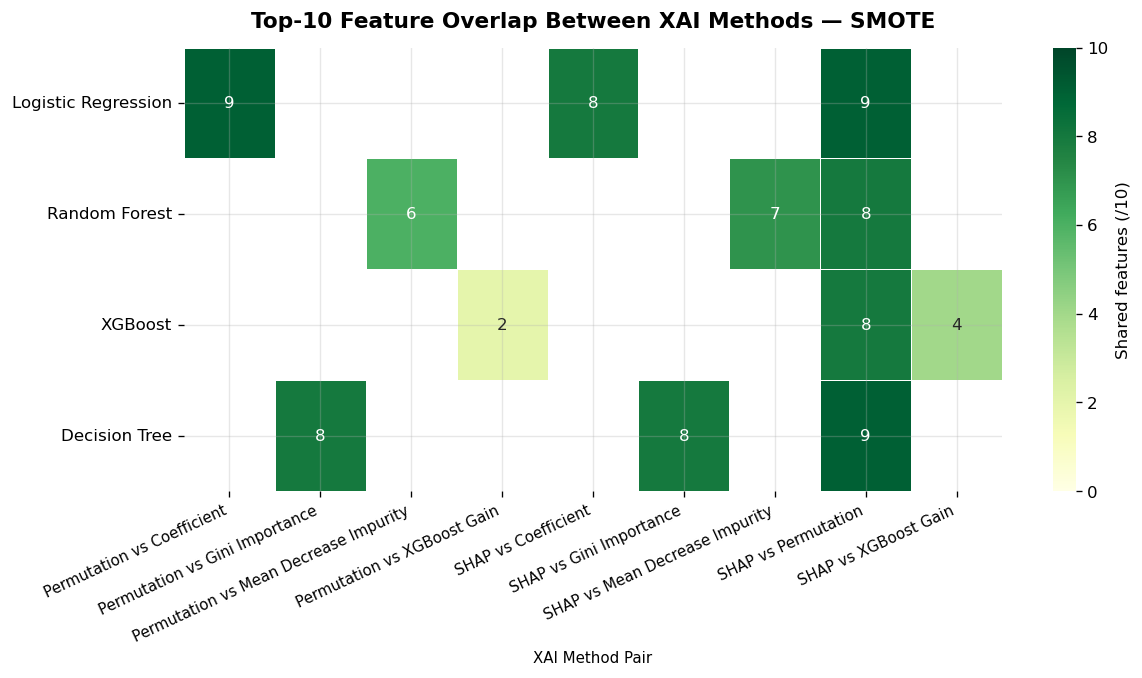

Saved figure to: ../results/figures/xai_method_consistency/overlap_heatmap_smote.png
SMOTE mean Top-N Overlap: 7.167
Pair-level means:
Pair
Permutation vs Coefficient               9.0
Permutation vs Gini Importance           8.0
Permutation vs Mean Decrease Impurity    6.0
Permutation vs XGBoost Gain              2.0
SHAP vs Coefficient                      8.0
SHAP vs Gini Importance                  8.0
SHAP vs Mean Decrease Impurity           7.0
SHAP vs Permutation                      8.5
SHAP vs XGBoost Gain                     4.0



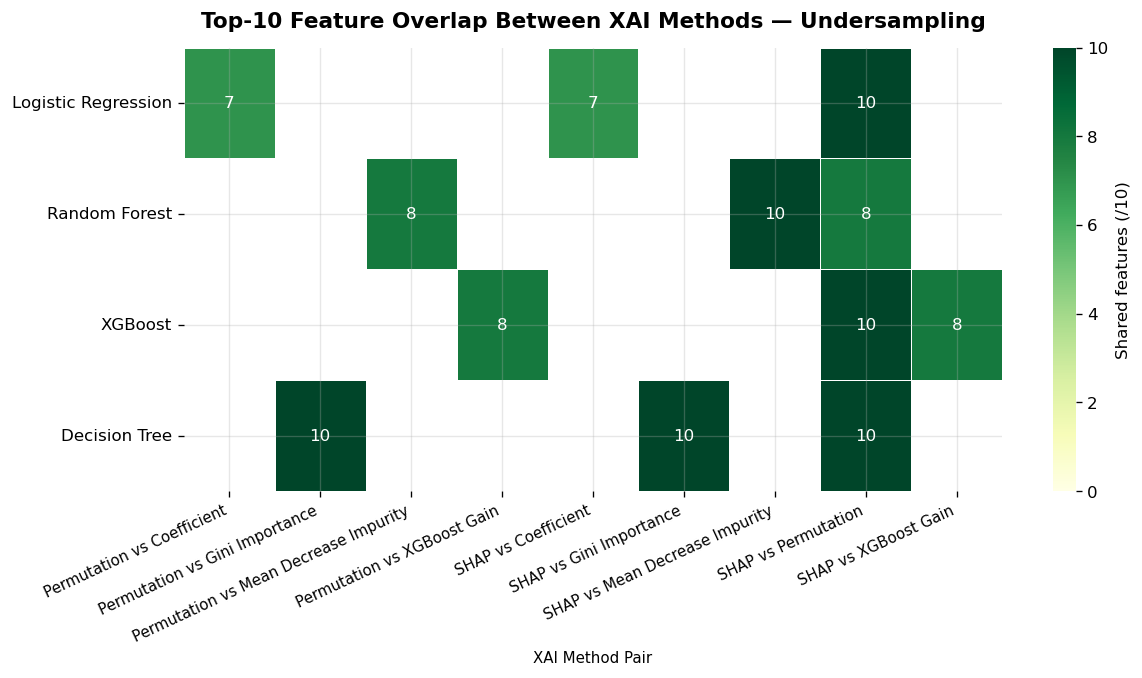

Saved figure to: ../results/figures/xai_method_consistency/overlap_heatmap_undersampling.png
Undersampling mean Top-N Overlap: 8.833
Pair-level means:
Pair
Permutation vs Coefficient                7.0
Permutation vs Gini Importance           10.0
Permutation vs Mean Decrease Impurity     8.0
Permutation vs XGBoost Gain               8.0
SHAP vs Coefficient                       7.0
SHAP vs Gini Importance                  10.0
SHAP vs Mean Decrease Impurity           10.0
SHAP vs Permutation                       9.5
SHAP vs XGBoost Gain                      8.0



In [6]:
for strategy in STRATEGIES:
    plot_strategy_heatmap(
        summary_df=summary_df,
        strategy=strategy,
        value_col="Top-N Overlap",
        title=f"Top-{TOP_N} Feature Overlap Between XAI Methods — {{strategy}}",
        cmap="YlGn",
        fmt=".0f",
        vmin=0,
        vmax=TOP_N,
        cbar_label=f"Shared features (/{TOP_N})",
        filename_prefix="overlap_heatmap"
    )


---
# Section 5 — Jaccard Similarity Overview, Plotted Separately per Strategy

This section creates one standalone Jaccard similarity heatmap per preprocessing strategy. Jaccard similarity is normalised to [0, 1] and complements the overlap count by accounting for the full union of both top-10 sets.


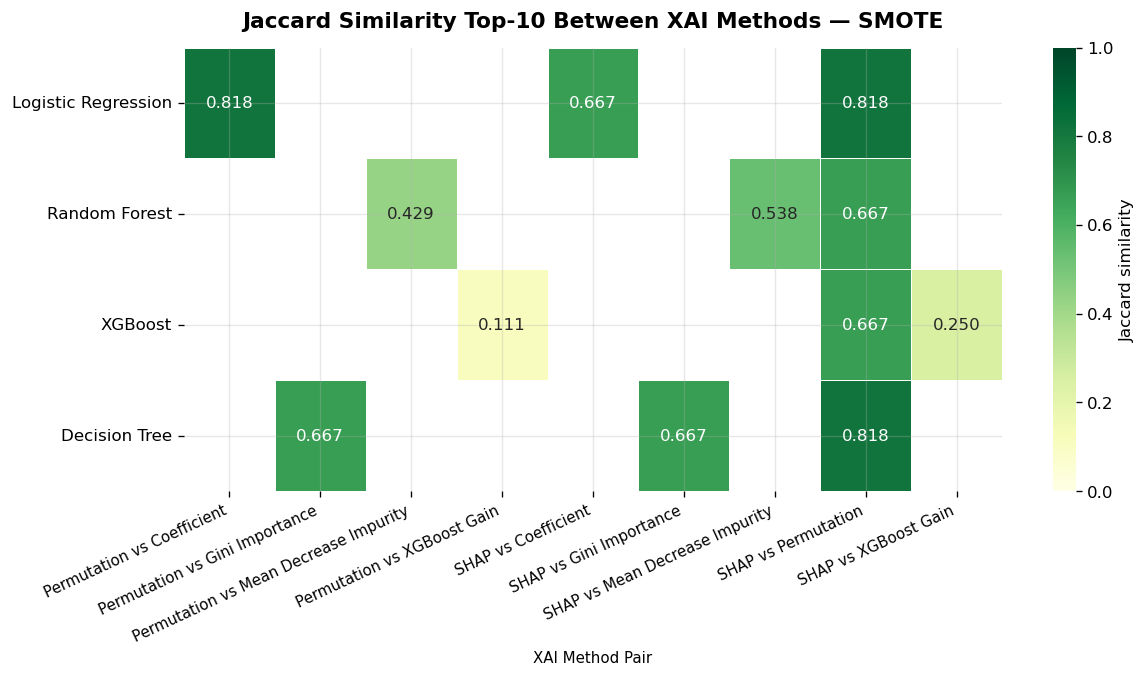

Saved figure to: ../results/figures/xai_method_consistency/jaccard_heatmap_smote.png
SMOTE mean Jaccard Similarity: 0.593
Pair-level means:
Pair
Permutation vs Coefficient               0.818
Permutation vs Gini Importance           0.667
Permutation vs Mean Decrease Impurity    0.429
Permutation vs XGBoost Gain              0.111
SHAP vs Coefficient                      0.667
SHAP vs Gini Importance                  0.667
SHAP vs Mean Decrease Impurity           0.538
SHAP vs Permutation                      0.742
SHAP vs XGBoost Gain                     0.250



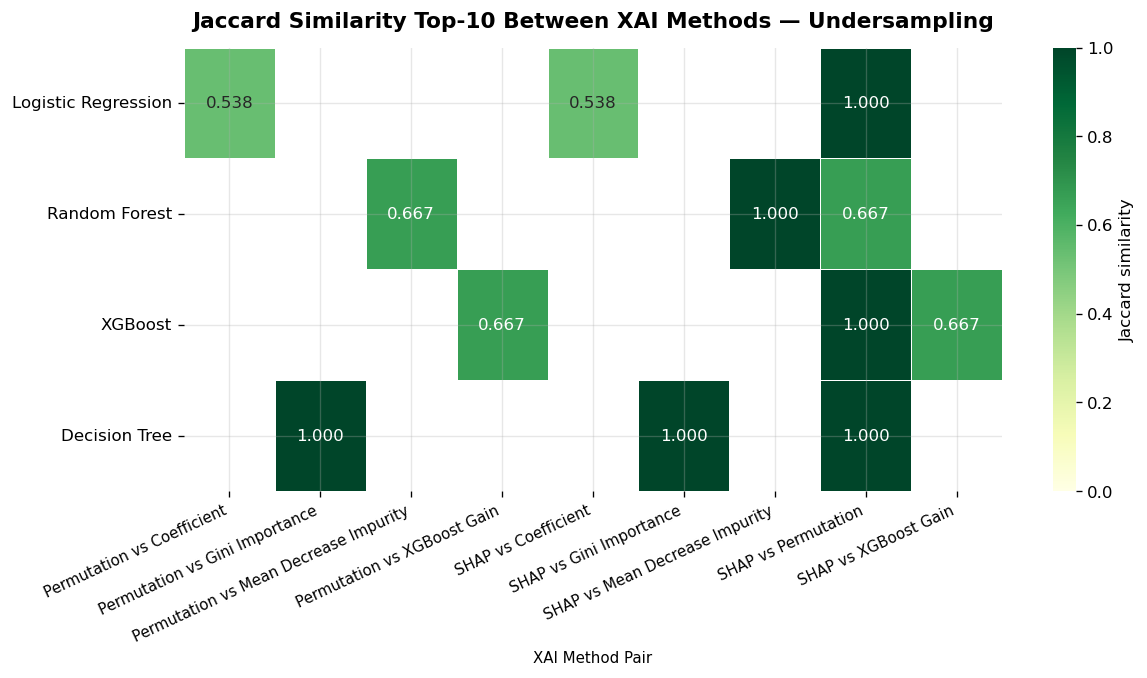

Saved figure to: ../results/figures/xai_method_consistency/jaccard_heatmap_undersampling.png
Undersampling mean Jaccard Similarity: 0.812
Pair-level means:
Pair
Permutation vs Coefficient               0.538
Permutation vs Gini Importance           1.000
Permutation vs Mean Decrease Impurity    0.667
Permutation vs XGBoost Gain              0.667
SHAP vs Coefficient                      0.538
SHAP vs Gini Importance                  1.000
SHAP vs Mean Decrease Impurity           1.000
SHAP vs Permutation                      0.917
SHAP vs XGBoost Gain                     0.667



In [7]:
for strategy in STRATEGIES:
    plot_strategy_heatmap(
        summary_df=summary_df,
        strategy=strategy,
        value_col="Jaccard Similarity",
        title=f"Jaccard Similarity Top-{TOP_N} Between XAI Methods — {{strategy}}",
        cmap="YlGn",
        fmt=".3f",
        vmin=0,
        vmax=1,
        cbar_label="Jaccard similarity",
        filename_prefix="jaccard_heatmap"
    )


In [8]:
display_df = summary_df[[
    "Model", "Strategy", "Method A", "Method B",
    "Top-N Overlap", "Spearman ρ", "Jaccard Similarity"
]].copy().sort_values(["Strategy", "Model"], ascending=[True, False]).reset_index(drop=True)

display_df["Top-N Overlap"] = display_df["Top-N Overlap"].apply(
    lambda x: f"{int(x)}/{TOP_N}"
)

print(f"XAI Method Consistency Summary — Top-{TOP_N}, all model × strategy combinations")
print("=" * 90)
display(display_df)

print()
print("Grand means across all model × strategy × method-pair combinations:")
raw = summary_df.copy()
print(f"  Spearman ρ:         {raw['Spearman ρ'].mean():.3f}")
print(f"  Jaccard Similarity: {raw['Jaccard Similarity'].mean():.3f}")
print(f"  Top-N Overlap:      {raw['Top-N Overlap'].mean():.1f} / {TOP_N}")

print()
print("Mean Spearman ρ per strategy:")
print(raw.groupby("Strategy")["Spearman ρ"].agg(["mean", "min", "max"]).round(3).to_string())

print()
print("Mean Spearman ρ per method pair, averaged over all strategies:")
print(raw.groupby("Pair")["Spearman ρ"].agg(["mean", "min", "max"]).round(3).to_string())

summary_output_path = f"{FIGURE_DIR}xai_method_consistency_summary_top{TOP_N}.csv"
raw.to_csv(summary_output_path, index=False)
print()
print(f"Saved summary table to: {summary_output_path}")


XAI Method Consistency Summary — Top-10, all model × strategy combinations


,Model,Strategy,Method A,Method B,Top-N Overlap,Spearman ρ,Jaccard Similarity
0,XGBoost,SMOTE,SHAP,Permutation,8/10,0.8102,0.6667
1,XGBoost,SMOTE,SHAP,XGBoost Gain,4/10,0.4946,0.2500
2,XGBoost,SMOTE,Permutation,XGBoost Gain,2/10,0.2824,0.1111
3,Random Forest,SMOTE,SHAP,Permutation,8/10,0.6208,0.6667
4,Random Forest,SMOTE,SHAP,Mean Decrease Impurity,7/10,0.9180,0.5385
5,Random Forest,SMOTE,Permutation,Mean Decrease Impurity,6/10,0.4228,0.4286
6,Logistic Regression,SMOTE,SHAP,Permutation,9/10,0.8472,0.8182
7,Logistic Regression,SMOTE,SHAP,Coefficient,8/10,0.8842,0.6667
8,Logistic Regression,SMOTE,Permutation,Coefficient,9/10,0.7955,0.8182
9,Decision Tree,SMOTE,SHAP,Permutation,9/10,0.7209,0.8182



Grand means across all model × strategy × method-pair combinations:
  Spearman ρ:         0.766
  Jaccard Similarity: 0.703
  Top-N Overlap:      8.0 / 10

Mean Spearman ρ per strategy:
                mean    min    max
Strategy                          
SMOTE          0.702  0.282  0.971
Undersampling  0.830  0.635  0.982

Mean Spearman ρ per method pair, averaged over all strategies:
                                        mean    min    max
Pair                                                      
Permutation vs Coefficient             0.821  0.796  0.846
Permutation vs Gini Importance         0.680  0.655  0.705
Permutation vs Mean Decrease Impurity  0.604  0.423  0.785
Permutation vs XGBoost Gain            0.459  0.282  0.635
SHAP vs Coefficient                    0.914  0.884  0.943
SHAP vs Gini Importance                0.976  0.971  0.982
SHAP vs Mean Decrease Impurity         0.922  0.918  0.926
SHAP vs Permutation                    0.783  0.621  0.889
SHAP vs XGBoost Gai